In [80]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [81]:
I = cv2.imread('I.jpg', cv2.IMREAD_GRAYSCALE)
J = cv2.imread('J.jpg', cv2.IMREAD_GRAYSCALE)

I = cv2.resize(I, None, fx=0.5, fy=0.5)
J = cv2.resize(J, None, fx=0.5, fy=0.5)

In [82]:
difference = cv2.absdiff(I, J)

(np.float64(-0.5), np.float64(159.5), np.float64(119.5), np.float64(-0.5))

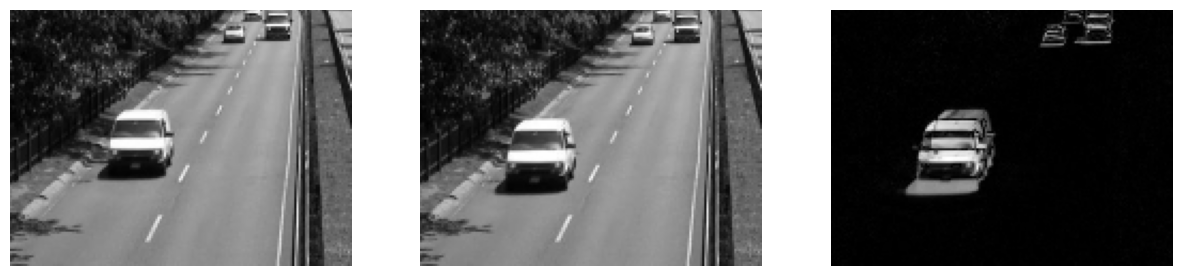

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(I, cmap='gray')
axes[0].axis('off')

axes[1].imshow(J, cmap='gray')
axes[1].axis('off')

axes[2].imshow(difference, cmap='gray')
axes[2].axis('off')

In [84]:
W = 7
W2 = 5
dX = dY = 5

In [85]:
def optical_flow_block(I, J, W2=3, dX=3, dY=3):
    u = np.zeros(I.shape).astype(np.float32)
    v = np.zeros(I.shape).astype(np.float32)

    for j in range(W2 * 2, I.shape[0] - W2 * 2):
        for i in range(W2 * 2, I.shape[1] - W2 * 2):
            IO = I[j - W2:j + W2 + 1, i - W2:i + W2 + 1].astype(np.float32)
            x, y = 0 ,0
            most_similar = -1

            for l in range(-dX, dX + 1):
                for k in range(-dY, dY + 1):
                    JO = J[j + l - W2:j + l + W2 + 1, i + k - W2:i + k + W2 + 1].astype(np.float32)
                    dist = np.sum(np.square(IO - JO))

                    if most_similar == -1 or dist < most_similar:
                        most_similar = dist
                        x = k
                        y = l

                u[j, i] = x
                v[j, i] = y

    return u, v

In [86]:
u, v = optical_flow_block(I, J, W2=5, dX=5, dY=5)

In [87]:
def vis_flow(u, v):
    magnitude, angle = cv2.cartToPolar(u.astype(np.float32), v.astype(np.float32))
    magnitude_normalized = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)

    HSV = np.zeros((u.shape[0], u.shape[1], 3), dtype=np.uint8)
    HSV[:,:,0] = (angle * 90 / np.pi).astype(np.uint8)
    HSV[:,:,1] = magnitude_normalized.astype(np.uint8)
    HSV[:,:,2] = 255

    RGB = cv2.cvtColor(HSV, cv2.COLOR_HSV2RGB)

    plt.imshow(RGB)
    plt.show()

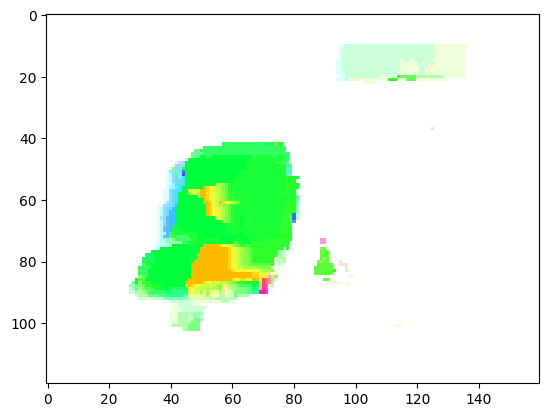

In [88]:
vis_flow(u, v)

In [89]:
I2 = cv2.imread('cm1.png')
I2 = cv2.cvtColor(I2, cv2.COLOR_BGR2GRAY)
J2 = cv2.imread('cm2.png')
J2 = cv2.cvtColor(J2, cv2.COLOR_BGR2GRAY)

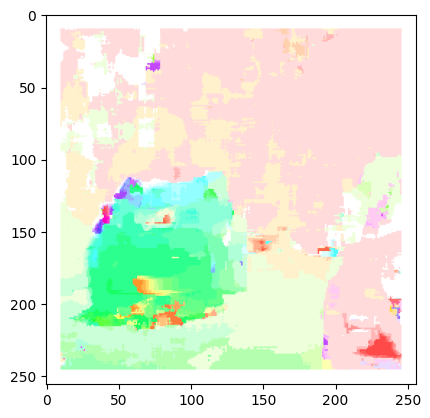

In [90]:
u2, v2 = optical_flow_block(I2, J2, W2, dX, dY)

vis_flow(u2, v2)

In [91]:
I = cv2.imread('I.jpg', cv2.IMREAD_GRAYSCALE)
J = cv2.imread('J.jpg', cv2.IMREAD_GRAYSCALE)

In [92]:
def pyramid(im, max_scale):
    images =[im]
    for k in range(1, max_scale):
        images.append(cv2.resize(images[k - 1], (0, 0), fx=0.5, fy=0.5))
    return images

In [101]:
def optical_flow_pyramid(I, J, W2, dX, dY, max_scale):
    pyrI = pyramid(I, max_scale)
    pyrJ = pyramid(J, max_scale)

    u_total = np.zeros_like(pyrI[-1], dtype=np.float32)
    v_total = np.zeros_like(pyrI[-1], dtype=np.float32)

    for scale in reversed(range(max_scale)):
        I_small = pyrI[scale]
        J_small = pyrJ[scale]
        h, w = I_small.shape

        if u_total.shape != I_small.shape:
            u_total = cv2.resize(u_total, (w, h), interpolation=cv2.INTER_LINEAR) * 2
            v_total = cv2.resize(v_total, (w, h), interpolation=cv2.INTER_LINEAR) * 2

        I_warped = np.zeros_like(I_small)
        for y in range(h):
            for x in range(w):
                new_y = int(np.clip(round(y - v_total[y, x]), 0, h - 1))
                new_x = int(np.clip(round(x - u_total[y, x]), 0, w - 1))
                I_warped[y, x] = I_small[new_y, new_x]

        u, v = optical_flow_block(I_warped, J_small, W2, dY, dX)
        u_total += u
        v_total += v

        vis_flow(u, v)

    u_total = cv2.resize(u_total, (I.shape[1], I.shape[0]), interpolation=cv2.INTER_LINEAR) * (I.shape[1] / pyrI[0].shape[1])
    v_total = cv2.resize(v_total, (I.shape[1], I.shape[0]), interpolation=cv2.INTER_LINEAR) * (I.shape[0] / pyrI[0].shape[0])



    return u_total, v_total

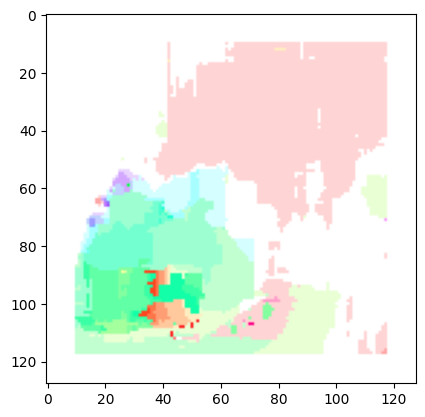

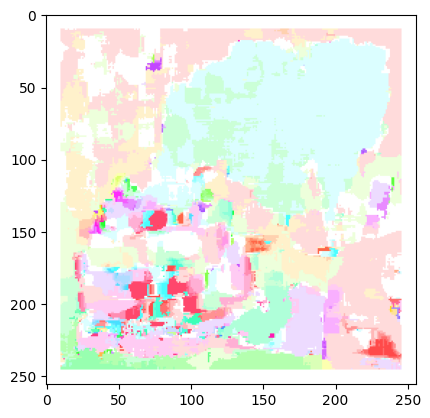

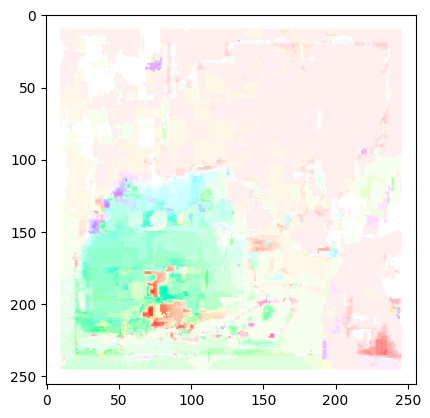

In [102]:
u4, v4 = optical_flow_pyramid(I2, J2, 5, 5, 5, 2)

vis_flow(u4, v4)

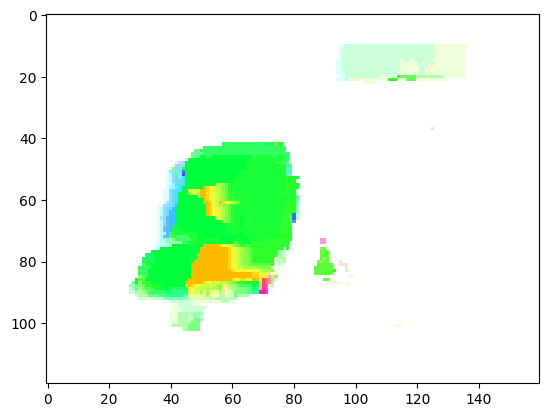

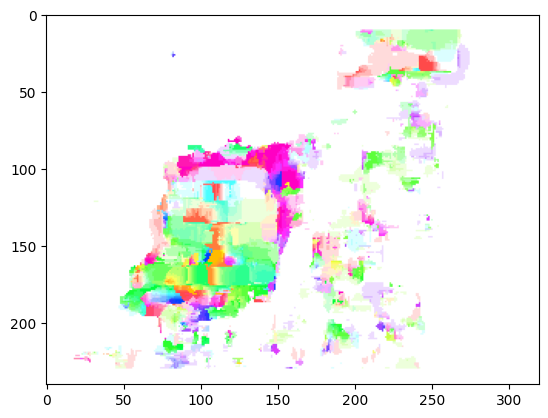

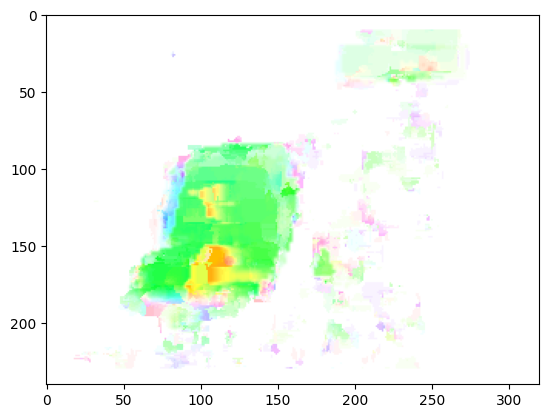

In [103]:
u3, v3 = optical_flow_pyramid(I, J, 5, 5, 5, 2)

vis_flow(u3, v3)

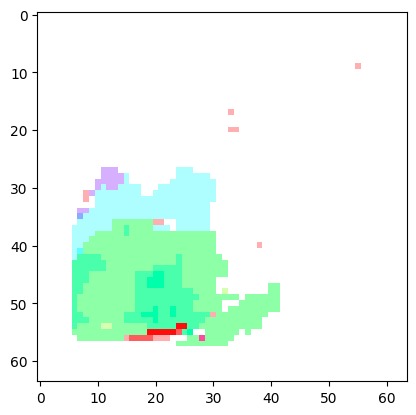

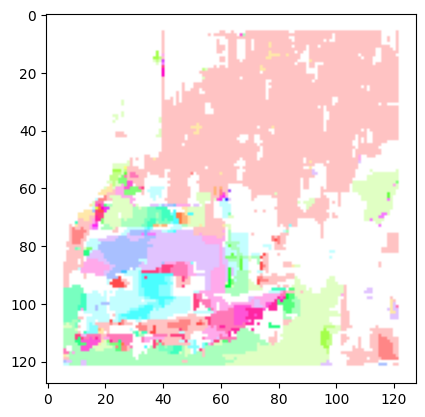

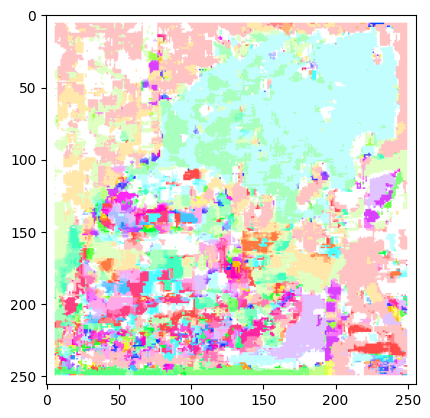

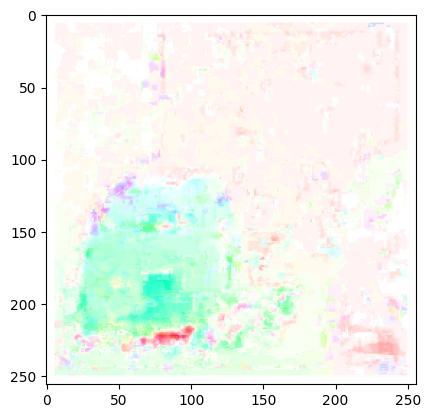

In [104]:
u4, v4 = optical_flow_pyramid(I2, J2, 3, 3, 3, 3)

vis_flow(u4, v4)